# Kaggle Dataset Explorer
## Schnelle Datenanalyse für Portfolio-Projekte

Dieses Notebook hilft dir dabei, Kaggle-Datasets schnell zu explorieren und zu entscheiden, ob sie für dein Portfolio-Projekt geeignet sind.

---

## 1. Setup & Daten laden



In [45]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from core.data import load_from_kaggle

# Styling für bessere Visualisierungen
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# GeoPy with Nominatim to estimate lat, lon from city name
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import os
import time

# Models
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.inspection import permutation_importance

# import module for Score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import cross_val_score

In [2]:
# ===== HIER DATASET-LINK EINFÜGEN =====
full_link = r"https://www.kaggle.com/datasets/orvile/european-cities-weather-prediction-dataset"
dataset_link = full_link.split("/datasets/")[-1]
# ======================================

destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

print(f"📦 Lade Dataset: {dataset_name}")
files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
)

print(f"✅ {len(files)} Datei(en) gefunden:")
for i, file in enumerate(files, 1):
    print(f"   {i}. {file}")


📦 Lade Dataset: european-cities-weather-prediction-dataset
Destination directory '../data/raw\european-cities-weather-prediction-dataset' already exists with files. Skipping download (replace=False).
✅ 10 Datei(en) gefunden:
   1. .~lock.weather_prediction_dataset_FS_noROMA.csv#
   2. .~lock.weather_prediction_dataset_light.csv#
   3. metadata.txt
   4. readme.md
   5. weather_prediction_dataset.csv
   6. weather_prediction_dataset_FS.csv
   7. weather_prediction_dataset_FS_noROMA.csv
   8. weather_prediction_dataset_light.csv
   9. weather_prediction_dataset_map.jpg
   10. weather_prediction_picnic_labels.csv




## 2. Daten einlesen & erste Inspektion



In [17]:

# Erste CSV-Datei laden (oder bei Bedarf anpassen)
# file_path = "/".join([destination, dataset_name, files[0]])
# df = pd.read_csv(file_path)

# print(f"📊 Geladene Datei: {files[0]}")
# print(f"📏 Shape: {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten\n")

file_weather_light = '../data/raw/european-cities-weather-prediction-dataset/weather_prediction_dataset_light.csv'
file_picnic_label  = '../data/raw/european-cities-weather-prediction-dataset/weather_prediction_picnic_labels.csv'
file_weather_full  = '../data/raw/european-cities-weather-prediction-dataset/weather_prediction_dataset.csv'
# file_weather_FS    = '../data/raw/european-cities-weather-prediction-dataset/weather_prediction_dataset_FS.csv'
file_weather_FS    = '../data/raw/european-cities-weather-prediction-dataset/weather_prediction_dataset_FS_noROMA.csv'

# Load the datasets from the specified CSV files
weather_light = pd.read_csv(file_weather_light, 
                            delimiter=',', encoding='ascii')

print(f"📊 Geladene Datei: {file_weather_light}")
print(f"📏 Shape: {weather_light.shape[0]:,} Zeilen × {weather_light.shape[1]} Spalten\n")

picnic_labels = pd.read_csv(file_picnic_label, 
                             delimiter=',', encoding='ascii')
print(f"📊 Geladene Datei: {file_picnic_label}")
print(f"📏 Shape: {picnic_labels.shape[0]:,} Zeilen × {picnic_labels.shape[1]} Spalten\n")

# For extended analysis, you could also load the complete dataset if needed
weather_full = pd.read_csv(file_weather_full, 
                           delimiter=',', encoding='ascii')
print(f"📊 Geladene Datei: {file_weather_full}")
print(f"📏 Shape: {weather_full.shape[0]:,} Zeilen × {weather_full.shape[1]} Spalten\n")

# For extended analysis, you could also load the complete dataset if needed
weather_FS = pd.read_csv(file_weather_FS, 
                           delimiter=',', encoding='ascii')
print(f"📊 Geladene Datei: {file_weather_FS}")
print(f"📏 Shape: {weather_FS.shape[0]:,} Zeilen × {weather_FS.shape[1]} Spalten\n")

# Convert the DATE column to datetime. The DATE is given as an integer (likely in YYYYMMDD format)
for df in [weather_light, picnic_labels, weather_full, weather_FS]:
    df['DATE'] = pd.to_datetime(df['DATE'].astype(str), format='%Y%m%d', errors='coerce')

print('Data loaded and DATE column converted to datetime.')

weather_FS.sample(3)


📊 Geladene Datei: ../data/raw/european-cities-weather-prediction-dataset/weather_prediction_dataset_light.csv
📏 Shape: 3,654 Zeilen × 91 Spalten

📊 Geladene Datei: ../data/raw/european-cities-weather-prediction-dataset/weather_prediction_picnic_labels.csv
📏 Shape: 3,654 Zeilen × 18 Spalten

📊 Geladene Datei: ../data/raw/european-cities-weather-prediction-dataset/weather_prediction_dataset.csv
📏 Shape: 3,654 Zeilen × 165 Spalten

📊 Geladene Datei: ../data/raw/european-cities-weather-prediction-dataset/weather_prediction_dataset_FS_noROMA.csv
📏 Shape: 62,118 Zeilen × 15 Spalten

Data loaded and DATE column converted to datetime.


,DATE,MONTH,cloud_cover,wind_speed,wind_gust,humidity,pressure,global_radiation,precipitation,sunshine,temp_mean,temp_min,temp_max,city,picnic_weather
15830,2003-04-29,4,4.0,5.5,17.0,0.67,1.0088,2.02,0.09,7.1,15.6,10.9,19.4,DUSSELDORF,False
13480,2006-11-23,11,6.0,6.9,12.6,0.72,NaN,0.38,0.12,3.0,6.0,1.9,10.0,DRESDEN,False
10667,2009-03-13,3,5.0,2.3,8.0,0.78,1.0204,1.26,0.00,6.3,7.7,4.2,12.6,DE_BILT,False




---

## 3. Datenqualität & Struktur



In [4]:

print("=" * 80)
print("📋 DATENÜBERSICHT weather_light")
print("=" * 80)

# Grundlegende Statistiken
print(f"\n🔢 Dimensionen: {weather_light.shape[0]:,} Zeilen × {weather_light.shape[1]} Spalten")
print(f"🔄 Duplikate: {weather_light.duplicated().sum():,} ({weather_light.duplicated().sum()/len(weather_light)*100:.2f}%)")
print(f"💾 Speichernutzung: {weather_light.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("=" * 80)
print("📋 DATENÜBERSICHT picnic_labels")
print("=" * 80)

# Grundlegende Statistiken
print(f"\n🔢 Dimensionen: {picnic_labels.shape[0]:,} Zeilen × {picnic_labels.shape[1]} Spalten")
print(f"🔄 Duplikate: {weather_light.duplicated().sum():,} ({picnic_labels.duplicated().sum()/len(picnic_labels)*100:.2f}%)")
print(f"💾 Speichernutzung: {picnic_labels.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("=" * 80)
print("📋 DATENÜBERSICHT weather_full")
print("=" * 80)

# Grundlegende Statistiken
print(f"\n🔢 Dimensionen: {weather_full.shape[0]:,} Zeilen × {weather_full.shape[1]} Spalten")
print(f"🔄 Duplikate: {weather_full.duplicated().sum():,} ({weather_full.duplicated().sum()/len(weather_full)*100:.2f}%)")
print(f"💾 Speichernutzung: {weather_full.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("=" * 80)
print("📋 DATENÜBERSICHT weather_FS")
print("=" * 80)

# Grundlegende Statistiken
print(f"\n🔢 Dimensionen: {weather_FS.shape[0]:,} Zeilen × {weather_FS.shape[1]} Spalten")
print(f"🔄 Duplikate: {weather_FS.duplicated().sum():,} ({weather_FS.duplicated().sum()/len(weather_FS)*100:.2f}%)")
print(f"💾 Speichernutzung: {weather_FS.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


📋 DATENÜBERSICHT weather_light

🔢 Dimensionen: 3,654 Zeilen × 91 Spalten
🔄 Duplikate: 0 (0.00%)
💾 Speichernutzung: 2.54 MB
📋 DATENÜBERSICHT picnic_labels

🔢 Dimensionen: 3,654 Zeilen × 18 Spalten
🔄 Duplikate: 0 (0.00%)
💾 Speichernutzung: 0.09 MB
📋 DATENÜBERSICHT weather_full

🔢 Dimensionen: 3,654 Zeilen × 165 Spalten
🔄 Duplikate: 0 (0.00%)
💾 Speichernutzung: 4.60 MB
📋 DATENÜBERSICHT weather_FS

🔢 Dimensionen: 62,118 Zeilen × 15 Spalten
🔄 Duplikate: 0 (0.00%)
💾 Speichernutzung: 9.57 MB


In [5]:
# Func Def: Overview(df) Übersicht entwerfen, um immer mal wieder einen schnellen Überblick über die wichtigsten "Metadaten" zu bekommen
def overview(df):
    '''
    Erstelle einen Überblick über einige wichtige Eigenschaften der Spalten eines DataFrames.
    VARs
        df: Der zu betrachtende DataFrame
    RETURNS:
        None
    '''
    df = df.copy()
    display(pd.DataFrame({'dtype': df.dtypes,
                          'total': df.count(),
                          'missing_n': df.isna().sum(),
                          'missing_%': df.isna().mean()*100,
                          'uniques_n': df.nunique(),
                          'uniques': [df[col].unique() for col in df.columns]
                         }))

In [6]:
overview(weather_FS)

,dtype,total,missing_n,missing_%,uniques_n,uniques
DATE,datetime64[ns],62118,0,0.000000,3654,"[2000-01-01 00:00:00, 2000-01-02 00:00:00, 200..."
MONTH,int64,62118,0,0.000000,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
cloud_cover,float64,43848,18270,29.411765,11,"[8.0, 5.0, 7.0, 3.0, 4.0, 1.0, 0.0, 6.0, 2.0, ..."
wind_speed,float64,43848,18270,29.411765,140,"[nan, 2.5, 3.7, 6.1, 3.8, 4.0, 5.2, 4.8, 4.3, ..."
wind_gust,float64,25578,36540,58.823529,271,"[nan, 8.0, 9.0, 13.0, 15.0, 12.0, 11.0, 7.0, 5..."
humidity,float64,54810,7308,11.764706,84,"[0.89, 0.87, 0.81, 0.79, 0.9, 0.85, 0.84, 0.88..."
pressure,float64,51156,10962,17.647059,692,"[1.0286, 1.0318, 1.0314, 1.0262, 1.0246, 1.024..."
global_radiation,float64,54810,7308,11.764706,413,"[0.2, 0.25, 0.5, 0.63, 0.51, 0.56, 0.54, 0.11,..."
precipitation,float64,62118,0,0.000000,526,"[0.03, 0.0, 0.35, 0.07, 0.65, 0.09, 0.12, 0.42..."
sunshine,float64,47502,14616,23.529412,185,"[0.0, 3.7, 6.9, 5.7, 4.3, 7.5, 7.6, 2.8, 0.3, ..."


In [7]:
# Detaillierte Spaltenübersicht
# column_info = pd.DataFrame({
#     "Datentyp": df.dtypes,
#     "Fehlende Werte": df.isnull().sum(),
#     "Fehlend %": (df.isnull().sum() / len(df) * 100).round(2),
#     "Unique Werte": df.nunique(),
#     "Beispielwerte": [df[col].dropna().sample(min(3, df[col].notna().sum())).tolist() 
#                       if df[col].notna().sum() > 0 else [] 
#                       for col in df.columns]
# })

# column_info = column_info.sort_values("Fehlend %", ascending=False)
# column_info


In [18]:
# overview(weather_light)
# overview(picnic_labels)
# overview(weather_full)
# for name in weather_light.columns:
#     print(name)
# for name in weather_full.columns:
#     print("'" + name + "',")
for name in picnic_labels.columns:
    print("'" + name + "',")


'DATE',
'BASEL_picnic_weather',
'BUDAPEST_picnic_weather',
'DE_BILT_picnic_weather',
'DRESDEN_picnic_weather',
'DUSSELDORF_picnic_weather',
'HEATHROW_picnic_weather',
'KASSEL_picnic_weather',
'LJUBLJANA_picnic_weather',
'MAASTRICHT_picnic_weather',
'MALMO_picnic_weather',
'MONTELIMAR_picnic_weather',
'MUENCHEN_picnic_weather',
'OSLO_picnic_weather',
'PERPIGNAN_picnic_weather',
'SONNBLICK_picnic_weather',
'STOCKHOLM_picnic_weather',
'TOURS_picnic_weather',


In [19]:
# MultiIndex-Spalten in flache Strings umwandeln (z. B. "Basel_A_bis_2023")
from enum import unique


c_names = picnic_labels.columns
# Spaltennamen aufteilen: nur am ersten '_'
split_cols = [st.split('_', maxsplit=1) for st in c_names[2:]]
c_names[2]
split_cols[0][0]
len(split_cols)
cit = [split_cols[i][0] for i in range(len(split_cols))]
set(cit)
# para = [split_cols[i][1] for i in range(len(split_cols))]
# set(para)
# pd.DataFrame(cit).unique()
# weather_full.columns = ['_'.join(col).strip() for col in weather_full.columns.values]

# # Spaltennamen aufteilen: nur am ersten '_'
# split_cols = weather_full.columns.str.split('_', n=1, expand=True)
# type(split_cols)
# split_cols
# city = split_cols[0].unique()
# parameter = split_cols[1].unique()
# city

{'BUDAPEST',
 'DE',
 'DRESDEN',
 'DUSSELDORF',
 'HEATHROW',
 'KASSEL',
 'LJUBLJANA',
 'MAASTRICHT',
 'MALMO',
 'MONTELIMAR',
 'MUENCHEN',
 'OSLO',
 'PERPIGNAN',
 'SONNBLICK',
 'STOCKHOLM',
 'TOURS'}

In [20]:
col_names = ['Date', 'Month',
             'cloud_cover', 'humidity', 'pressure', 'global_radiation',
             'precipitation', 'sunshine', 'temp_mean', 'temp_min', 'temp_max',
             'lat', 'lon', 'city']

cities = ['BASEL', 'BUDAPEST', 'DE', 'DRESDEN', 'DUSSELDORF', 'HEATHROW', 'KASSEL', 'LJUBLJANA',
          'MAASTRICHT', 'MALMO', 'MONTELIMAR', 'MUENCHEN', 'OSLO', 'PERPIGNAN',
          'SONNBLICK', 'STOCKHOLM', 'TOURS']

df_basel = weather_full.loc[:,['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation',
                               'BASEL_precipitation', 'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max']]
df_basel['lat'] = 47.5596
df_basel['lon'] = 7.5886
df_basel['city'] = 'Basel'
df_basel.columns = col_names
df_basel

,Date,Month,cloud_cover,humidity,pressure,global_radiation,precipitation,sunshine,temp_mean,temp_min,temp_max,lat,lon,city
0,2000-01-01,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,3.9,47.5596,7.5886,Basel
1,2000-01-02,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,4.8,47.5596,7.5886,Basel
2,2000-01-03,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,4.8,47.5596,7.5886,Basel
3,2000-01-04,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,7.5,47.5596,7.5886,Basel
4,2000-01-05,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,8.6,47.5596,7.5886,Basel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3649,2009-12-28,12,7,0.82,1.0084,0.28,0.42,0.3,3.2,1.0,4.8,47.5596,7.5886,Basel
3650,2009-12-29,12,7,0.92,1.0028,0.22,1.68,0.2,4.5,2.4,10.0,47.5596,7.5886,Basel
3651,2009-12-30,12,8,0.92,0.9979,0.07,1.54,0.0,8.5,7.5,11.5,47.5596,7.5886,Basel
3652,2009-12-31,12,7,0.93,0.9958,0.17,0.57,0.1,6.6,4.3,7.9,47.5596,7.5886,Basel


In [21]:
weather_FS

,DATE,MONTH,cloud_cover,wind_speed,wind_gust,humidity,pressure,global_radiation,precipitation,sunshine,temp_mean,temp_min,temp_max,city,picnic_weather
0,2000-01-01,1,8.0,NaN,NaN,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,3.9,BASEL,False
1,2000-01-02,1,8.0,NaN,NaN,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,4.8,BASEL,False
2,2000-01-03,1,5.0,NaN,NaN,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,4.8,BASEL,False
3,2000-01-04,1,7.0,NaN,NaN,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,7.5,BASEL,False
4,2000-01-05,1,5.0,NaN,NaN,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,8.6,BASEL,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62113,2009-12-28,12,NaN,3.7,NaN,0.95,1.0011,0.22,1.50,NaN,6.2,1.8,10.6,TOURS,False
62114,2009-12-29,12,NaN,5.3,NaN,0.89,0.9966,0.24,0.40,NaN,10.4,6.2,14.5,TOURS,False
62115,2009-12-30,12,NaN,3.8,NaN,0.88,0.9939,0.24,1.00,NaN,10.0,8.7,11.3,TOURS,False
62116,2009-12-31,12,NaN,4.2,NaN,0.88,0.9933,0.58,0.02,NaN,8.5,6.2,10.9,TOURS,False


In [22]:
weather_FS.city.unique()

array(['BASEL', 'BUDAPEST', 'DE_BILT', 'DRESDEN', 'DUSSELDORF',
       'HEATHROW', 'KASSEL', 'LJUBLJANA', 'MAASTRICHT', 'MALMO',
       'MONTELIMAR', 'MUENCHEN', 'OSLO', 'PERPIGNAN', 'SONNBLICK',
       'STOCKHOLM', 'TOURS'], dtype=object)

In [23]:
import requests
import time

def get_coordinates(city_name, user_agent="MeineApp/1.0 (meine@email.de)"):
    base_url = "https://nominatim.openstreetmap.org/search"
    params = {
        "q": city_name,
        "format": "json",
        "limit": 1,
    }
    headers = {
        "User-Agent": user_agent,
    }

    try:
        response = requests.get(base_url, params=params, headers=headers)
        response.raise_for_status()
        data = response.json()
        if data:
            return float(data[0]["lat"]), float(data[0]["lon"])
        else:
            return None, None
    except Exception as e:
        print(f"Fehler: {e}")
        return None, None


In [ ]:
# Beispielaufruf
lat, lon = get_coordinates("Berlin")
print(f"Lat: {lat}, Lon: {lon}")

Lat: 52.5173885, Lon: 13.3951309


In [ ]:
# from geopy.geocoders import Nominatim

from turtle import delay


geolocator = Nominatim(user_agent="my_app")
# location = geolocator.geocode("Berlin")
# print((location.latitude, location.longitude))

for cit in weather_FS.city.unique():
    time.sleep(2)  # Pause von 1 Sekunde
    location = geolocator.geocode(cit)
    print((cit, location.latitude, location.longitude))


('BASEL', 47.5581077, 7.5878261)
('BUDAPEST', 47.4978789, 19.0402383)
('DE_BILT', 52.1445592, 5.1737773)
('DRESDEN', 51.0493286, 13.7381437)
('DUSSELDORF', 51.2254018, 6.7763137)
('HEATHROW', 51.467739, -0.4587801)
('KASSEL', 51.3157833, 9.4978479)
('LJUBLJANA', 46.0500268, 14.5069289)
('MAASTRICHT', 50.8512438, 5.6909768)
('MALMO', 55.6052931, 13.0001566)
('MONTELIMAR', 44.5579391, 4.750318)
('MUENCHEN', 48.1371079, 11.5753822)
('OSLO', 59.9133301, 10.7389701)
('PERPIGNAN', 42.6985304, 2.8953121)
('ROMA', 41.8933203, 12.4829321)
('SONNBLICK', 46.9003462, 13.383461)
('STOCKHOLM', 59.3251172, 18.0710935)
('TOURS', 47.3900474, 0.6889268)


In [ ]:
unique_cities = weather_FS['city'].unique()

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import pandas as pd

geolocator = Nominatim(user_agent="geoapi")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

def get_coordinates(city):
    try:
        location = geocode(city)
        if location:
            return (location.latitude, location.longitude)
        else:
            return (None, None)
    except:
        return (None, None)

city_coords = {}
for city in unique_cities:
    city_coords[city] = get_coordinates(city)

In [ ]:
weather_FS['lat'] = weather_FS['city'].map(lambda x: city_coords[x][0])
weather_FS['lon'] = weather_FS['city'].map(lambda x: city_coords[x][1])
weather_FS.head(3)

,DATE,MONTH,cloud_cover,wind_speed,wind_gust,humidity,pressure,global_radiation,precipitation,sunshine,temp_mean,temp_min,temp_max,city,picnic_weather,lat,lon
0,2000-01-01,1,8.0,NaN,NaN,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,3.9,BASEL,False,47.558108,7.587826
1,2000-01-02,1,8.0,NaN,NaN,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,4.8,BASEL,False,47.558108,7.587826
2,2000-01-03,1,5.0,NaN,NaN,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,4.8,BASEL,False,47.558108,7.587826




---

## Picnic Weather Prediction Model

In [55]:
# Function to createw, fit and evaluate a model for a CITY

# For this analysis, we will predict BASEL_picnic_weather using BASEL weather features.
def fit_model_for_city(city_name, df_weather, df_picnic, feature_cols, save_plot=False, show_plot=True):

    X = df_weather[feature_cols]
    y = df_picnic[city_name+'_picnic_weather']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train a Random Forest Classifier
    clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    clf.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = clf.predict(X_test)

    # Calculate prediction accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print('Prediction accuracy for ' + city_name + ' picnic weather:', accuracy)

    # Calculate ROC curve and AUC
    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    print('AUC:', roc_auc)

    # Compute permutation importance
    perm_importance = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42)
    importances = perm_importance.importances_mean

    # Create a DataFrame for feature importance
    feature_importance_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
    feature_importance_df.sort_values(by='importance', ascending=True, inplace=True)

    print('Permutation importance calculated for the features.')

    print(f'RandomForestClassifier \t\t\t|\t TEST \t\t|\t TRAIN')
    print(f'-------------------------------------------------------------------------------------')
    print(f'True #IsBad:     \t\t\t|\t {(y_test==1).sum()} \t\t|\t {(y_train==1).sum()}')
    print(f'True #NotBad:    \t\t\t|\t {(y_test==0).sum()} \t\t|\t {(y_train==0).sum()}')
    print(f'F1-Score:        \t\t\t|\t {f1_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{f1_score(y_train, clf.predict(X_train))*100:.2f} %')
    print(f'precision_score: \t\t\t|\t {precision_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{precision_score(y_train, clf.predict(X_train))*100:.2f} %')
    print(f'recall_score:    \t\t\t|\t {recall_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{recall_score(y_train, clf.predict(X_train))*100:.2f} %')
    print(f'accuracy_score:  \t\t\t|\t {accuracy_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{accuracy_score(y_train, clf.predict(X_train))*100:.2f} %')

    if save_plot:
        os.makedirs('../plots', exist_ok=True)

    # Model Evaluation and Visualization
    # Plot ROC Curve
    roc_fig = plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for ' + city_name + ' Picnic Weather Prediction')
    plt.legend(loc='lower right')
    if save_plot:
        roc_fig.savefig(f'../plots/ROC_{city_name}.png', bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close(roc_fig)

    # Plot Confusion Matrix using a heatmap
    cm = confusion_matrix(y_test, y_pred)
    cm_fig = plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix ' + city_name)
    if save_plot:
        cm_fig.savefig(f'../plots/Confusion_{city_name}.png', bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close(cm_fig)

    # Plot Permutation Importance
    imp_fig = plt.figure(figsize=(8, 6))
    plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color='skyblue')
    plt.xlabel('Mean Importance')
    plt.title('Permutation Importance of ' + city_name + ' Weather Features')
    if save_plot:
        imp_fig.savefig(f'../plots/Importance_{city_name}.png', bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close(imp_fig)

Prediction accuracy for BASEL picnic weather: 1.0
AUC: 1.0
Permutation importance calculated for the features.
RandomForestClassifier 			|	 TEST 		|	 TRAIN
-------------------------------------------------------------------------------------
True #IsBad:     			|	 189 		|	 748
True #NotBad:    			|	 542 		|	 2175
F1-Score:        			|	 100.00 % 	|	 100.00 %
precision_score: 			|	 100.00 % 	|	 100.00 %
recall_score:    			|	 100.00 % 	|	 100.00 %
accuracy_score:  			|	 100.00 % 	|	 100.00 %


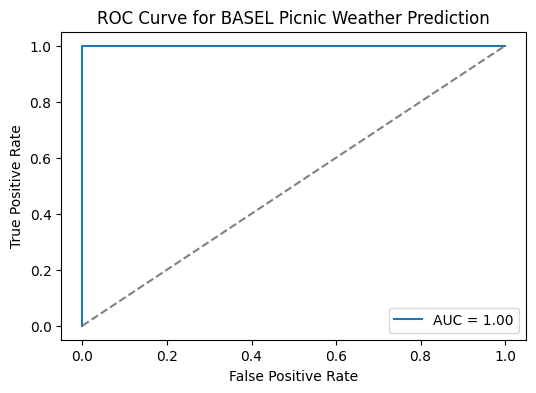

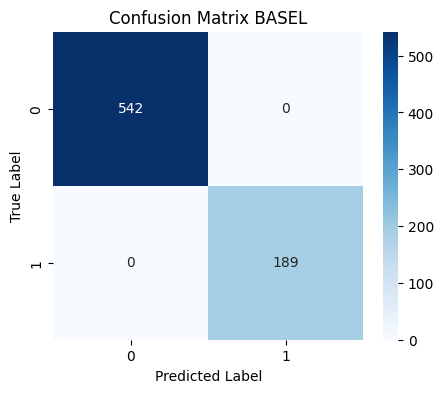

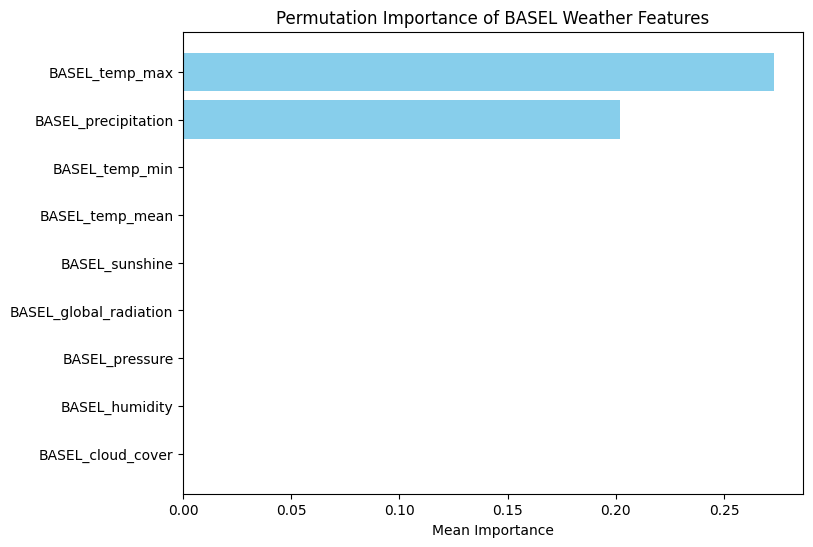

In [56]:
city_name = 'BASEL'
feature_cols = staedte_features[city_name]
fit_model_for_city(city_name, weather_light, picnic_labels, feature_cols, save_plot=True, show_plot=True)


In [57]:
staedte_features = {
    # 'BASEL': ['BASEL_cloud_cover', 'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation',
    #           'BASEL_precipitation', 'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max'],
    'BASEL': ['BASEL_cloud_cover', 'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation',
              'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max'],
    'DE_BILT': ['DE_BILT_cloud_cover', 'DE_BILT_humidity', 'DE_BILT_pressure', 'DE_BILT_global_radiation',
                'DE_BILT_precipitation', 'DE_BILT_sunshine', 'DE_BILT_temp_mean',
                'DE_BILT_temp_min', 'DE_BILT_temp_max'],
    'DRESDEN': ['DRESDEN_cloud_cover', 'DRESDEN_humidity', 'DRESDEN_global_radiation',
                'DRESDEN_precipitation', 'DRESDEN_sunshine', 'DRESDEN_temp_mean',
                'DRESDEN_temp_min', 'DRESDEN_temp_max'],
    'DUSSELDORF': ['DUSSELDORF_cloud_cover', 'DUSSELDORF_humidity', 'DUSSELDORF_pressure',
                   'DUSSELDORF_global_radiation', 'DUSSELDORF_precipitation', 'DUSSELDORF_sunshine',
                   'DUSSELDORF_temp_mean', 'DUSSELDORF_temp_min', 'DUSSELDORF_temp_max'],
    'HEATHROW': ['HEATHROW_cloud_cover', 'HEATHROW_humidity', 'HEATHROW_pressure', 'HEATHROW_global_radiation',
                 'HEATHROW_precipitation', 'HEATHROW_sunshine', 'HEATHROW_temp_mean',
                 'HEATHROW_temp_min', 'HEATHROW_temp_max'],
    'KASSEL': ['KASSEL_humidity', 'KASSEL_pressure', 'KASSEL_global_radiation', 'KASSEL_precipitation',
               'KASSEL_sunshine', 'KASSEL_temp_mean', 'KASSEL_temp_min', 'KASSEL_temp_max'],
    'MAASTRICHT': ['MAASTRICHT_cloud_cover', 'MAASTRICHT_humidity', 'MAASTRICHT_pressure', 'MAASTRICHT_global_radiation',
                   'MAASTRICHT_precipitation', 'MAASTRICHT_sunshine', 'MAASTRICHT_temp_mean', 'MAASTRICHT_temp_min',
                   'MAASTRICHT_temp_max'],
    'MALMO': ['MALMO_precipitation', 'MALMO_temp_mean', 'MALMO_temp_min', 'MALMO_temp_max'],
    'MUENCHEN': ['MUENCHEN_cloud_cover', 'MUENCHEN_humidity', 'MUENCHEN_pressure', 'MUENCHEN_global_radiation',
                 'MUENCHEN_precipitation', 'MUENCHEN_sunshine', 'MUENCHEN_temp_mean', 'MUENCHEN_temp_min', 'MUENCHEN_temp_max'],
    # 'SONNBLICK': ['SONNBLICK_cloud_cover', 'SONNBLICK_humidity', 'SONNBLICK_global_radiation', 'SONNBLICK_precipitation',
    #               'SONNBLICK_sunshine', 'SONNBLICK_temp_mean', 'SONNBLICK_temp_min', 'SONNBLICK_temp_max'],
    'TOURS': ['TOURS_humidity', 'TOURS_pressure', 'TOURS_global_radiation', 'TOURS_precipitation',
              'TOURS_temp_mean', 'TOURS_temp_min', 'TOURS_temp_max'],
}

# Beispiel: Zugriff per Stadtname
# city_name = 'TOURS'
# feature_cols = staedte_features[city_name]
# fit_model_for_city(city_name, weather_light, picnic_labels, feature_cols)

unique_cities = list(staedte_features.keys()) # weather_FS['city'].unique()

for city in unique_cities:
    fit_model_for_city(city, weather_light, picnic_labels, 
                       staedte_features[city], save_plot=True, show_plot=False)


Prediction accuracy for BASEL picnic weather: 0.9028727770177839
AUC: 0.9652375095179523
Permutation importance calculated for the features.
RandomForestClassifier 			|	 TEST 		|	 TRAIN
-------------------------------------------------------------------------------------
True #IsBad:     			|	 189 		|	 748
True #NotBad:    			|	 542 		|	 2175
F1-Score:        			|	 81.75 % 	|	 100.00 %
precision_score: 			|	 79.50 % 	|	 100.00 %
recall_score:    			|	 84.13 % 	|	 100.00 %
accuracy_score:  			|	 90.29 % 	|	 100.00 %
Prediction accuracy for DE_BILT picnic weather: 1.0
AUC: 1.0
Permutation importance calculated for the features.
RandomForestClassifier 			|	 TEST 		|	 TRAIN
-------------------------------------------------------------------------------------
True #IsBad:     			|	 164 		|	 639
True #NotBad:    			|	 567 		|	 2284
F1-Score:        			|	 100.00 % 	|	 100.00 %
precision_score: 			|	 100.00 % 	|	 100.00 %
recall_score:    			|	 100.00 % 	|	 100.00 %
accuracy_score:  			|	 100.

In [19]:
# For this analysis, we will predict BASEL_picnic_weather using BASEL weather features.

# Define feature columns and target variable
feature_cols = ['BASEL_cloud_cover', 'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation', 
                'BASEL_precipitation', 'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max']

# X = df[feature_cols]
# y = df['BASEL_picnic_weather']
X = weather_light[feature_cols]
y = picnic_labels['BASEL_picnic_weather']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Calculate prediction accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Prediction accuracy for BASEL picnic weather:', accuracy)

# Calculate ROC curve and AUC
y_prob = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print('AUC:', roc_auc)

# Compute permutation importance
perm_importance = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42)
importances = perm_importance.importances_mean

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feature_importance_df.sort_values(by='importance', ascending=True, inplace=True)

print('Permutation importance calculated for the features.')

Prediction accuracy for BASEL picnic weather: 1.0
AUC: 1.0
Permutation importance calculated for the features.


## Model Evaluation and Visualization

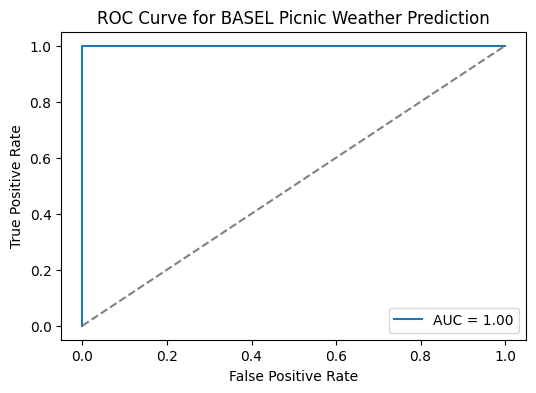

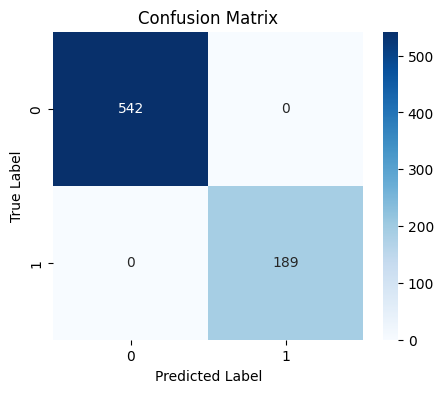

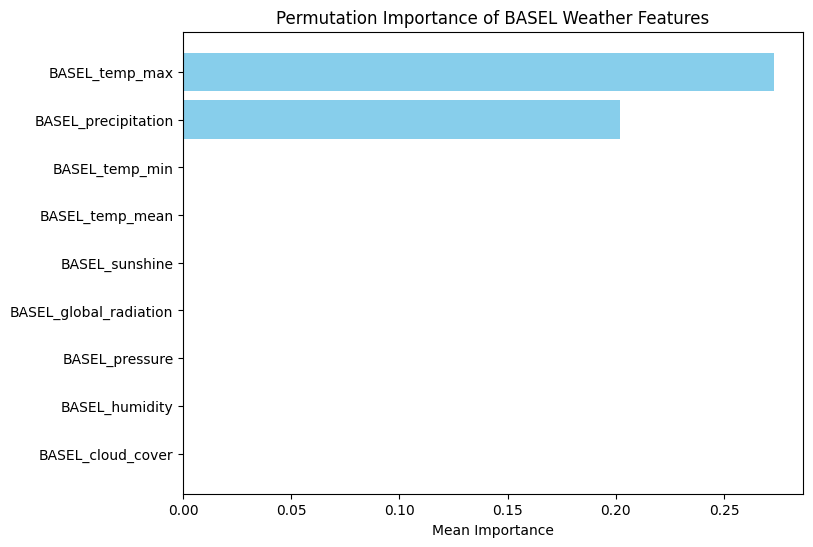

In [20]:
# Plot ROC Curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for BASEL Picnic Weather Prediction')
plt.legend(loc='lower right')
plt.show()

# Plot Confusion Matrix using a heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Plot Permutation Importance
plt.figure(figsize=(8, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color='skyblue')
plt.xlabel('Mean Importance')
plt.title('Permutation Importance of BASEL Weather Features')
plt.show()



---

## 4. Numerische Variablen analysieren



In [15]:

# Statistiken für numerische Spalten
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    print(f"📊 {len(numeric_cols)} numerische Spalten gefunden\n")
    display(df[numeric_cols].describe().round(2).T)
else:
    print("⚠️ Keine numerischen Spalten gefunden")



📊 14 numerische Spalten gefunden



,count,mean,std,min,25%,50%,75%,max
MONTH,62118.0,6.52,3.45,1.00,4.00,7.00,10.00,12.00
cloud_cover,43848.0,5.27,2.39,-99.00,4.00,6.00,7.00,9.00
wind_speed,43848.0,3.33,1.89,0.00,2.00,2.90,4.30,16.30
wind_gust,25578.0,10.06,3.88,1.50,7.20,9.50,12.10,41.00
humidity,54810.0,0.75,0.14,0.10,0.66,0.77,0.86,1.00
pressure,51156.0,94.98,294.17,-99.00,1.01,1.02,1.02,1049.00
global_radiation,54810.0,1.35,0.96,0.01,0.52,1.17,2.09,4.42
precipitation,62118.0,0.23,0.58,0.00,0.00,0.00,0.20,16.04
sunshine,47502.0,4.85,4.41,-1.70,0.50,4.00,8.20,24.00
temp_mean,62118.0,10.05,8.37,-26.60,4.30,10.60,16.40,33.10


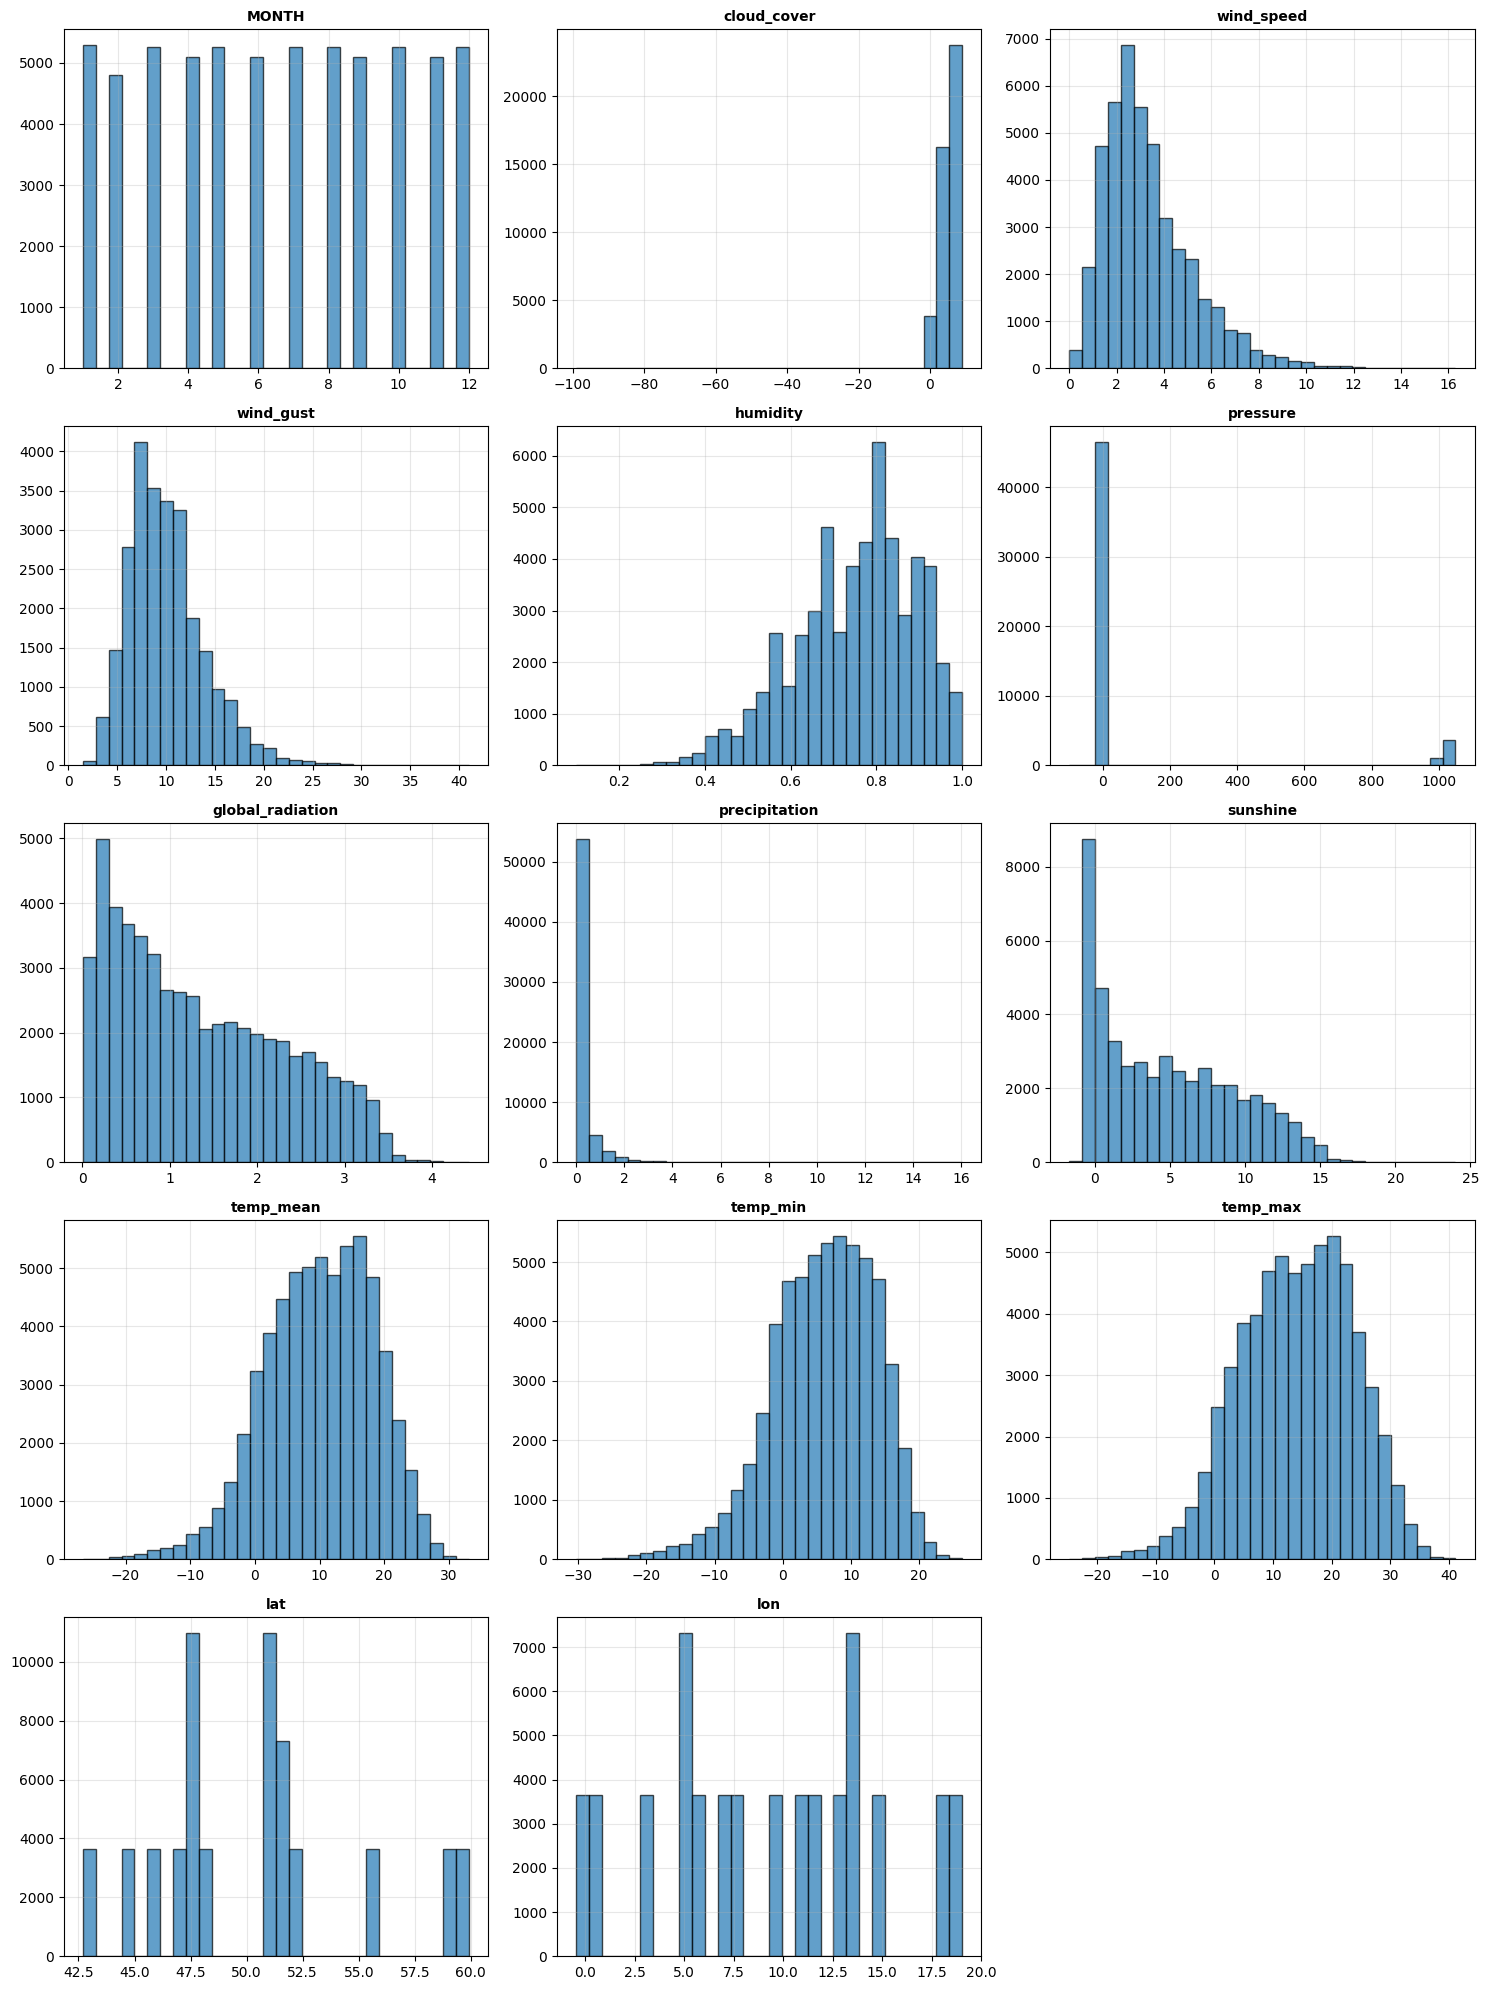

In [16]:
# Verteilungen der numerischen Variablen
if numeric_cols:
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if len(numeric_cols) > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        ax = axes[idx]
        df[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
        ax.set_title(f'{col}', fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3)
    
    # Leere Subplots ausblenden
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()




---

## 5. Kategorische Variablen analysieren



In [ ]:

# Kategorische Spalten identifizieren
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if categorical_cols:
    print(f"🏷️ {len(categorical_cols)} kategorische Spalten gefunden\n")
    
    cat_summary = pd.DataFrame({
        "Spalte": categorical_cols,
        "Unique Werte": [df[col].nunique() for col in categorical_cols],
        "Häufigste Werte": [df[col].value_counts().head(3).to_dict() for col in categorical_cols]
    })
    
    display(cat_summary)
else:
    print("⚠️ Keine kategorischen Spalten gefunden")


In [ ]:
# Top-Kategorien visualisieren (für Spalten mit wenigen Unique-Werten)
if categorical_cols:
    low_cardinality_cols = [col for col in categorical_cols if df[col].nunique() <= 20]
    
    if low_cardinality_cols:
        n_cols = min(2, len(low_cardinality_cols))
        n_rows = (len(low_cardinality_cols) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
        axes = axes.flatten() if len(low_cardinality_cols) > 1 else [axes]
        
        for idx, col in enumerate(low_cardinality_cols):
            ax = axes[idx]
            value_counts = df[col].value_counts().head(10)
            value_counts.plot(kind='barh', ax=ax, color='steelblue')
            ax.set_title(f'Top Kategorien: {col}', fontsize=10, fontweight='bold')
            ax.set_xlabel('Anzahl')
            ax.grid(alpha=0.3, axis='x')
        
        # Leere Subplots ausblenden
        for idx in range(len(low_cardinality_cols), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()




---

## 6. Korrelationsanalyse



In [ ]:

if len(numeric_cols) > 1:
    # Korrelationsmatrix
    corr_matrix = df[numeric_cols].corr()
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Obere Dreiecksmatrix maskieren
    
    sns.heatmap(
        corr_matrix, 
        mask=mask,
        annot=True, 
        fmt='.2f',
        cmap='RdBu', 
        center=0, 
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        ax=ax
    )
    
    ax.set_title('Korrelationsmatrix (numerische Variablen)', 
                 fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Stärkste Korrelationen finden
    print("\n🔗 Stärkste Korrelationen (|r| > 0.5):\n")
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.5:
                corr_pairs.append({
                    'Variable 1': corr_matrix.columns[i],
                    'Variable 2': corr_matrix.columns[j],
                    'Korrelation': corr_matrix.iloc[i, j]
                })
    
    if corr_pairs:
        corr_df = pd.DataFrame(corr_pairs).sort_values('Korrelation', 
                                                        key=abs, 
                                                        ascending=False)
        display(corr_df)
    else:
        print("Keine starken Korrelationen gefunden.")
else:
    print("⚠️ Nicht genügend numerische Variablen für Korrelationsanalyse")




---

## 7. Fehlende Werte visualisieren



In [ ]:

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    fig, ax = plt.subplots(figsize=(10, max(6, len(missing_data) * 0.4)))
    
    missing_percent = (missing_data / len(df) * 100)
    missing_percent.plot(kind='barh', ax=ax, color='coral')
    
    ax.set_title('Fehlende Werte pro Spalte', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prozent fehlend (%)')
    ax.grid(alpha=0.3, axis='x')
    
    # Werte als Text hinzufügen
    for i, v in enumerate(missing_percent):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ Keine fehlenden Werte im Dataset!")




---

## 8. Zusammenfassung & Bewertung



In [ ]:

print("=" * 80)
print("📝 DATASET-BEWERTUNG FÜR PORTFOLIO-PROJEKT")
print("=" * 80)

# Qualitätskriterien berechnen
data_quality = {
    "Datengröße": "✅ Gut" if len(df) > 5_000 else "⚠️ Klein" if len(df) > 1_000 else "❌ Zu klein",
    "Vollständigkeit": f"✅ {(1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.1f}%",
    "Duplikate": "✅ Keine" if df.duplicated().sum() == 0 else f"⚠️ {df.duplicated().sum()} gefunden",
    "Variablenvielfalt": f"{'✅' if df.shape[1] >= 10 else '⚠️'} {df.shape[1]} Spalten",
    "Numerische Features": f"{'✅' if len(numeric_cols) >= 5 else '⚠️'} {len(numeric_cols)} Spalten",
    "Kategorische Features": f"{'✅' if len(categorical_cols) >= 1 else '⚠️'} {len(categorical_cols)} Spalten"
}

for criterion, status in data_quality.items():
    print(f"{criterion:.<30} {status}")

print("\n" + "=" * 80)
print("💡 EMPFEHLUNG:")
print("=" * 80)

score = sum([
    len(df) > 5000,
    df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) < 0.1,
    df.duplicated().sum() < len(df) * 0.05,
    df.shape[1] >= 10,
    len(numeric_cols) >= 5
])

if score >= 4:
    print("✅ SEHR GUT - Dieses Dataset eignet sich hervorragend für ein Portfolio-Projekt!")
elif score >= 3:
    print("👍 OK - Dieses Dataset ist für ein Portfolio-Projekt geeignet.")
else:
    print("⚠️ BEDINGT - Überlege, ob dieses Dataset für dein Projekt ausreicht.")

print("\n📌 Nächste Schritte:")
print("   1. Definiere deine Forschungsfrage")
print("   2. Identifiziere relevante Features")
print("   3. Plane deine Analysestrategie")
print("   4. Beginne mit Feature Engineering & Modeling")
